# PPA Fraud Detection — Model Results

**Purpose:** Evidence for council review — model performance, temporal stability, HPO results, and feature importance.

**Data:** March 2025 → February 2026 · 123,423 scoring events · 5,559 fraud insertions (6.4%)

**Production model:** `fraud-detection@production` · AUC-PR 0.638 · AUC-ROC 0.927

In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

DB_PATH = '../ppa-fraud-detection-mlflow.db'

# Colour palette
C_BLUE   = '#2563EB'
C_GREEN  = '#16A34A'
C_ORANGE = '#EA580C'
C_RED    = '#DC2626'
C_GREY   = '#6B7280'
C_LIGHT  = '#E5E7EB'

plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'sans-serif',
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})
print('Setup complete.')

Setup complete.


## 1  Temporal Stability — Fixed Splits

Three models trained on expanding historical windows, each tested on the immediately following month.

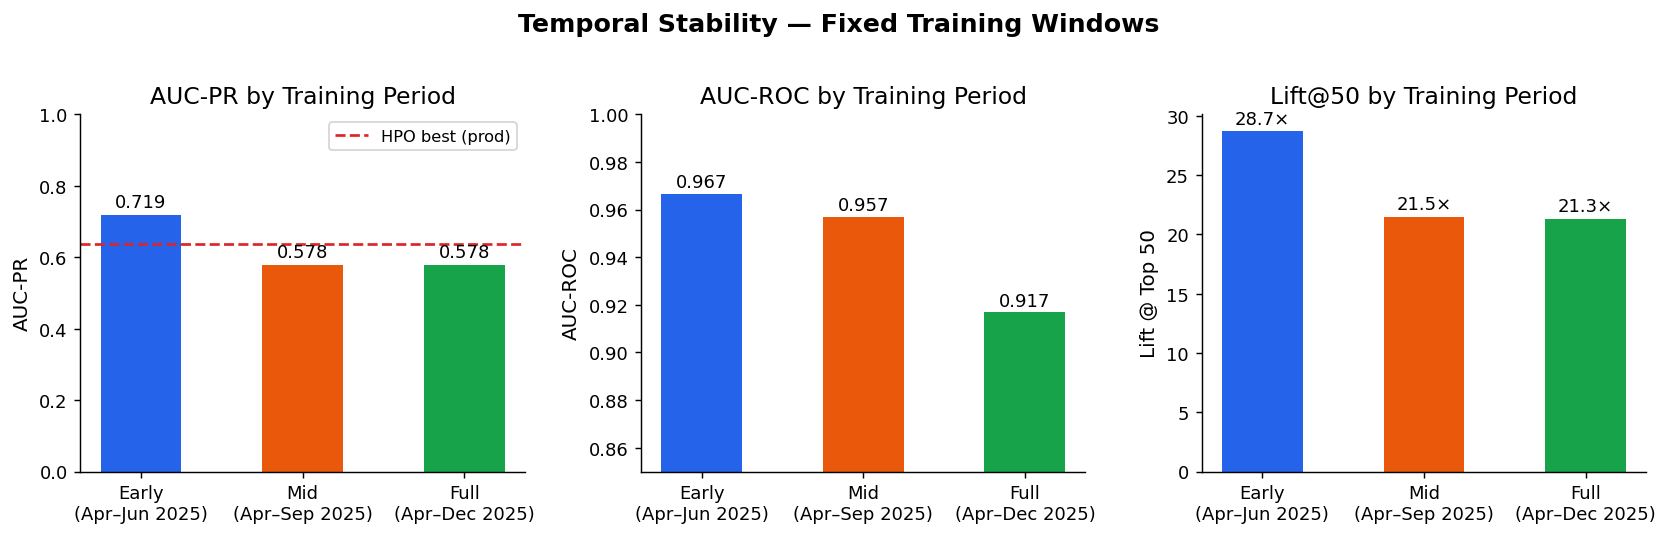

               period  auc_pr  auc_roc  lift_at_50  catch_rate  false_alarm
Early\n(Apr–Jun 2025)  0.7193   0.9666        28.7       0.664       0.0112
  Mid\n(Apr–Sep 2025)  0.5781   0.9570        21.5       0.502       0.0094
 Full\n(Apr–Dec 2025)  0.5778   0.9168        21.3       0.646       0.0132


In [2]:
# Temporal check results (from make temporal-check)
temporal = pd.DataFrame([
    {'period': 'Early\n(Apr–Jun 2025)',  'train_months': 3,  'test_month': 'Jul 2025',
     'auc_pr': 0.7193, 'auc_roc': 0.9666, 'lift_at_50': 28.7, 'catch_rate': 0.664, 'false_alarm': 0.0112,
     'fraud_count': 244, 'fraud_rate': 0.0327},
    {'period': 'Mid\n(Apr–Sep 2025)',   'train_months': 6,  'test_month': 'Oct 2025',
     'auc_pr': 0.5781, 'auc_roc': 0.9570, 'lift_at_50': 21.5, 'catch_rate': 0.502, 'false_alarm': 0.0094,
     'fraud_count': 273, 'fraud_rate': 0.0334},
    {'period': 'Full\n(Apr–Dec 2025)',  'train_months': 9,  'test_month': 'Feb 2026',
     'auc_pr': 0.5778, 'auc_roc': 0.9168, 'lift_at_50': 21.3, 'catch_rate': 0.646, 'false_alarm': 0.0132,
     'fraud_count': 553, 'fraud_rate': 0.0375},
])

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
fig.suptitle('Temporal Stability — Fixed Training Windows', fontsize=14, fontweight='bold', y=1.02)

colors = [C_BLUE, C_ORANGE, C_GREEN]

# AUC-PR
ax = axes[0]
bars = ax.bar(temporal['period'], temporal['auc_pr'], color=colors, width=0.5)
ax.axhline(0.638, color=C_RED, linestyle='--', linewidth=1.5, label='HPO best (prod)')
ax.set_ylim(0, 1)
ax.set_ylabel('AUC-PR')
ax.set_title('AUC-PR by Training Period')
for bar, val in zip(bars, temporal['auc_pr']):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.01, f'{val:.3f}', ha='center', va='bottom', fontsize=10)
ax.legend(fontsize=9)

# AUC-ROC
ax = axes[1]
bars = ax.bar(temporal['period'], temporal['auc_roc'], color=colors, width=0.5)
ax.set_ylim(0.85, 1.0)
ax.set_ylabel('AUC-ROC')
ax.set_title('AUC-ROC by Training Period')
for bar, val in zip(bars, temporal['auc_roc']):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.001, f'{val:.3f}', ha='center', va='bottom', fontsize=10)

# Lift@50
ax = axes[2]
bars = ax.bar(temporal['period'], temporal['lift_at_50'], color=colors, width=0.5)
ax.set_ylabel('Lift @ Top 50')
ax.set_title('Lift@50 by Training Period')
for bar, val in zip(bars, temporal['lift_at_50']):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.3, f'{val:.1f}×', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('../artifacts/plots/temporal_stability.png', bbox_inches='tight')
plt.show()
print(temporal[['period','auc_pr','auc_roc','lift_at_50','catch_rate','false_alarm']].to_string(index=False))

## 2  Expanding Window — Month-by-Month Performance

8 windows of 30-day test sets, accumulating training data from March 2025 forward.

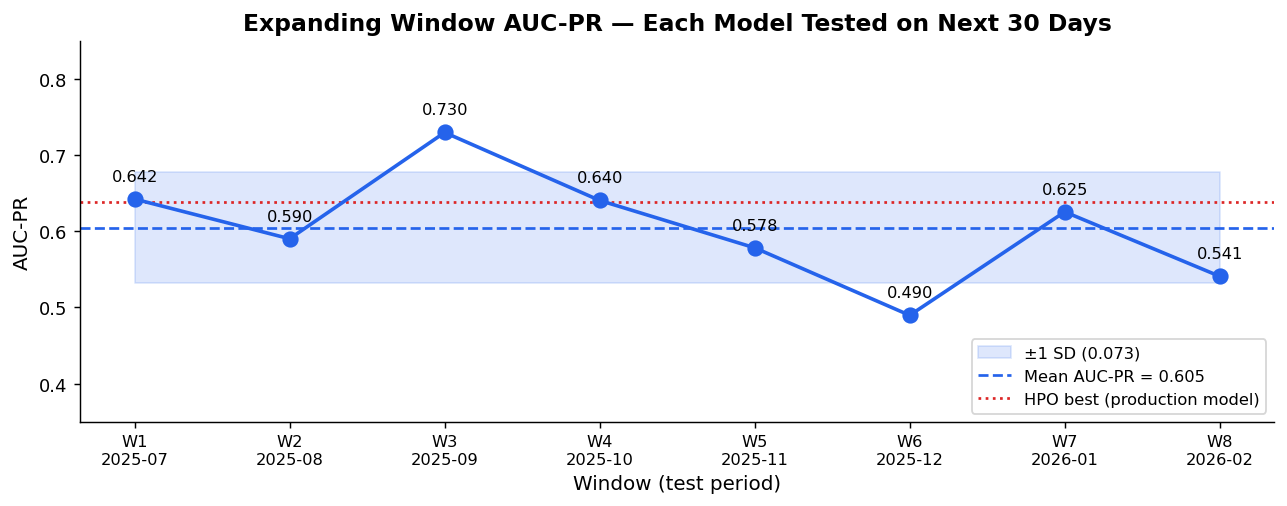

Mean AUC-PR: 0.6046 ± 0.0727
Min: 0.4897  Max: 0.7297


In [3]:
# Expanding window results (from make expanding-vanilla stdout)
# 8 windows, window_days=30, gap=7, train_start=2025-03-21, test_end=2026-02-01
# Approximate test window end dates (30-day windows starting ~Jun 2025 after 2 min windows)
import datetime

expanding = pd.DataFrame([
    {'window': 1, 'test_end': '2025-07', 'auc_pr': 0.6423},
    {'window': 2, 'test_end': '2025-08', 'auc_pr': 0.5902},
    {'window': 3, 'test_end': '2025-09', 'auc_pr': 0.7297},
    {'window': 4, 'test_end': '2025-10', 'auc_pr': 0.6405},
    {'window': 5, 'test_end': '2025-11', 'auc_pr': 0.5783},
    {'window': 6, 'test_end': '2025-12', 'auc_pr': 0.4897},
    {'window': 7, 'test_end': '2026-01', 'auc_pr': 0.6255},
    {'window': 8, 'test_end': '2026-02', 'auc_pr': 0.5409},
])

mean_auc = expanding['auc_pr'].mean()
std_auc  = expanding['auc_pr'].std()

fig, ax = plt.subplots(figsize=(10, 4))

ax.fill_between(expanding['window'],
                mean_auc - std_auc, mean_auc + std_auc,
                alpha=0.15, color=C_BLUE, label=f'±1 SD ({std_auc:.3f})')
ax.axhline(mean_auc, color=C_BLUE, linestyle='--', linewidth=1.5, label=f'Mean AUC-PR = {mean_auc:.3f}')
ax.axhline(0.638, color=C_RED, linestyle=':', linewidth=1.5, label='HPO best (production model)')
ax.plot(expanding['window'], expanding['auc_pr'], 'o-', color=C_BLUE, linewidth=2, markersize=8)

for _, row in expanding.iterrows():
    ax.annotate(f"{row['auc_pr']:.3f}", (row['window'], row['auc_pr']),
                textcoords='offset points', xytext=(0, 10), ha='center', fontsize=9)

ax.set_xticks(expanding['window'])
ax.set_xticklabels([f"W{int(w)}\n{d}" for w, d in zip(expanding['window'], expanding['test_end'])], fontsize=9)
ax.set_xlabel('Window (test period)')
ax.set_ylabel('AUC-PR')
ax.set_title('Expanding Window AUC-PR — Each Model Tested on Next 30 Days', fontweight='bold')
ax.set_ylim(0.35, 0.85)
ax.legend(loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig('../artifacts/plots/expanding_window.png', bbox_inches='tight')
plt.show()
print(f'Mean AUC-PR: {mean_auc:.4f} ± {std_auc:.4f}')
print(f'Min: {expanding["auc_pr"].min():.4f}  Max: {expanding["auc_pr"].max():.4f}')

## 3  HPO — 50-Trial Optuna Search

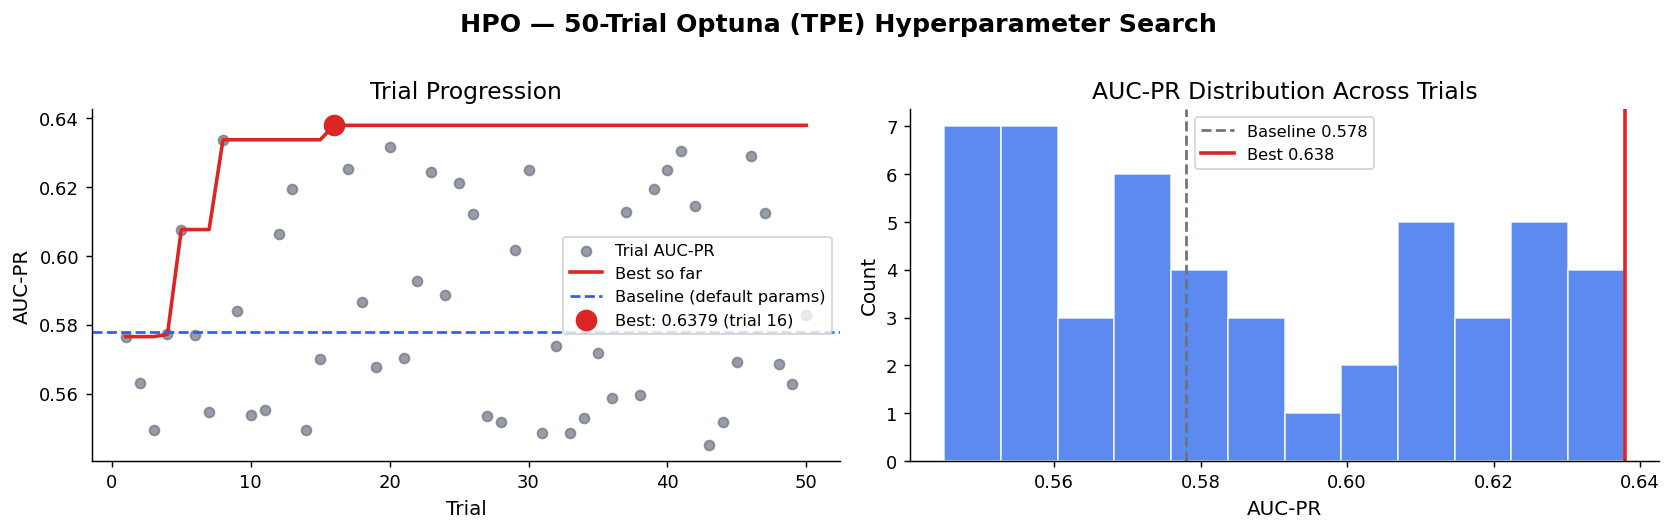

Best trial AUC-PR: 0.6379  AUC-ROC: 0.9265
Improvement over baseline: +0.0599 (10.4%)


In [4]:
conn = sqlite3.connect(DB_PATH)

hpo_runs = pd.read_sql_query('''
    SELECT r.run_uuid,
           MAX(CASE WHEN m.key = 'auc_pr'  THEN m.value END) as auc_pr,
           MAX(CASE WHEN m.key = 'auc_roc' THEN m.value END) as auc_roc
    FROM runs r
    JOIN metrics m ON r.run_uuid = m.run_uuid
    WHERE r.experiment_id = 2 AND r.status = 'FINISHED'
    GROUP BY r.run_uuid
    HAVING auc_pr IS NOT NULL
    ORDER BY r.start_time ASC
''', conn)
conn.close()

hpo_runs['trial'] = range(1, len(hpo_runs) + 1)
hpo_runs['best_so_far'] = hpo_runs['auc_pr'].cummax()
best_run = hpo_runs.loc[hpo_runs['auc_pr'].idxmax()]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('HPO — 50-Trial Optuna (TPE) Hyperparameter Search', fontsize=14, fontweight='bold', y=1.01)

# Trial progression
ax = axes[0]
ax.scatter(hpo_runs['trial'], hpo_runs['auc_pr'], color=C_GREY, s=30, alpha=0.7, label='Trial AUC-PR')
ax.plot(hpo_runs['trial'], hpo_runs['best_so_far'], color=C_RED, linewidth=2, label='Best so far')
ax.axhline(0.578, color=C_BLUE, linestyle='--', linewidth=1.5, label='Baseline (default params)')
ax.scatter([best_run['trial']], [best_run['auc_pr']], color=C_RED, s=120, zorder=5,
           label=f'Best: {best_run["auc_pr"]:.4f} (trial {int(best_run["trial"])})')
ax.set_xlabel('Trial')
ax.set_ylabel('AUC-PR')
ax.set_title('Trial Progression')
ax.legend(fontsize=9)

# Distribution
ax = axes[1]
ax.hist(hpo_runs['auc_pr'], bins=12, color=C_BLUE, alpha=0.75, edgecolor='white')
ax.axvline(0.578, color=C_GREY, linestyle='--', linewidth=1.5, label='Baseline 0.578')
ax.axvline(best_run['auc_pr'], color=C_RED, linestyle='-', linewidth=2, label=f'Best 0.638')
ax.set_xlabel('AUC-PR')
ax.set_ylabel('Count')
ax.set_title('AUC-PR Distribution Across Trials')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('../artifacts/plots/hpo_trials.png', bbox_inches='tight')
plt.show()
print(f'Best trial AUC-PR: {best_run["auc_pr"]:.4f}  AUC-ROC: {best_run["auc_roc"]:.4f}')
print(f'Improvement over baseline: +{best_run["auc_pr"] - 0.578:.4f} ({(best_run["auc_pr"]/0.578 - 1)*100:.1f}%)')

## 4  Threshold Analysis — Precision / Recall Trade-off

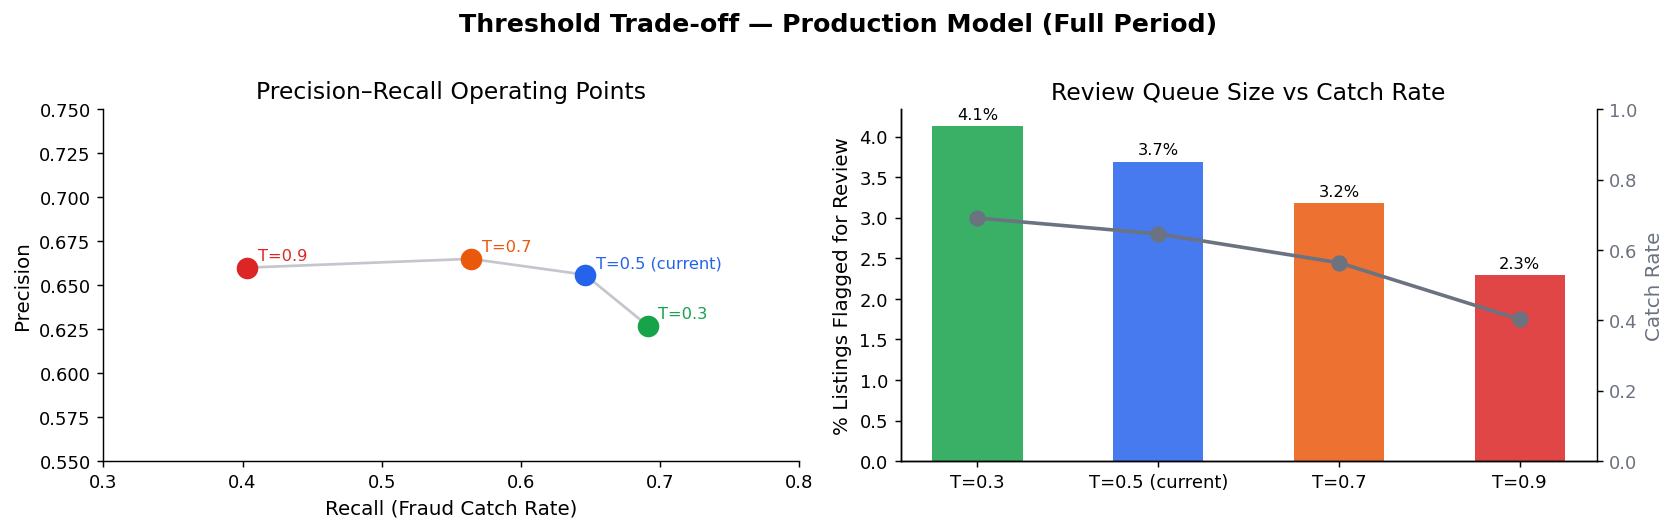

In [5]:
# Threshold operating points from temporal-check Period 3 (Full model, production equivalent)
thresholds = pd.DataFrame([
    {'threshold': 0.3,  'precision': 0.627, 'recall': 0.691, 'f1': 0.657, 'flagged_pct': 4.13, 'label': 'T=0.3'},
    {'threshold': 0.5,  'precision': 0.656, 'recall': 0.646, 'f1': 0.651, 'flagged_pct': 3.69, 'label': 'T=0.5 (current)'},
    {'threshold': 0.7,  'precision': 0.665, 'recall': 0.564, 'f1': 0.611, 'flagged_pct': 3.18, 'label': 'T=0.7'},
    {'threshold': 0.9,  'precision': 0.660, 'recall': 0.403, 'f1': 0.500, 'flagged_pct': 2.29, 'label': 'T=0.9'},
])

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Threshold Trade-off — Production Model (Full Period)', fontsize=14, fontweight='bold', y=1.01)

# Precision vs Recall
ax = axes[0]
colors_t = [C_GREEN, C_BLUE, C_ORANGE, C_RED]
for i, row in thresholds.iterrows():
    ax.scatter(row['recall'], row['precision'], s=120, color=colors_t[i], zorder=5)
    ax.annotate(row['label'], (row['recall'], row['precision']),
                textcoords='offset points', xytext=(6, 4), fontsize=9, color=colors_t[i])
ax.plot(thresholds['recall'], thresholds['precision'], 'o-', color=C_GREY, alpha=0.4, zorder=1)
ax.set_xlabel('Recall (Fraud Catch Rate)')
ax.set_ylabel('Precision')
ax.set_title('Precision–Recall Operating Points')
ax.set_xlim(0.3, 0.8)
ax.set_ylim(0.55, 0.75)

# Queue load vs recall
ax = axes[1]
bars = ax.bar(thresholds['label'], thresholds['flagged_pct'],
              color=colors_t, alpha=0.85, width=0.5)
ax2 = ax.twinx()
ax2.plot(range(len(thresholds)), thresholds['recall'], 'o-', color=C_GREY,
         linewidth=2, markersize=8, label='Catch rate')
ax2.set_ylabel('Catch Rate', color=C_GREY)
ax2.tick_params(axis='y', labelcolor=C_GREY)
ax2.set_ylim(0, 1)
ax.set_ylabel('% Listings Flagged for Review')
ax.set_title('Review Queue Size vs Catch Rate')
ax.spines['right'].set_visible(True)
for bar, val in zip(bars, thresholds['flagged_pct']):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.05, f'{val:.1f}%',
            ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('../artifacts/plots/threshold_tradeoff.png', bbox_inches='tight')
plt.show()

## 5  Feature Importance

2026/03/24 09:39:50 INFO mlflow.store.db.utils: Creating initial MLflow database tables...


2026/03/24 09:39:50 INFO mlflow.store.db.utils: Updating database tables


2026-03-24 09:39:50 INFO  [alembic.runtime.migration] Context impl SQLiteImpl.


2026-03-24 09:39:50 INFO  [alembic.runtime.migration] Will assume non-transactional DDL.


2026-03-24 09:39:50 INFO  [alembic.runtime.migration] Context impl SQLiteImpl.


2026-03-24 09:39:50 INFO  [alembic.runtime.migration] Will assume non-transactional DDL.


2026/03/24 09:39:50 INFO mlflow.store.db.utils: Creating initial MLflow database tables...


2026/03/24 09:39:50 INFO mlflow.store.db.utils: Updating database tables


2026-03-24 09:39:50 INFO  [alembic.runtime.migration] Context impl SQLiteImpl.


2026-03-24 09:39:50 INFO  [alembic.runtime.migration] Will assume non-transactional DDL.


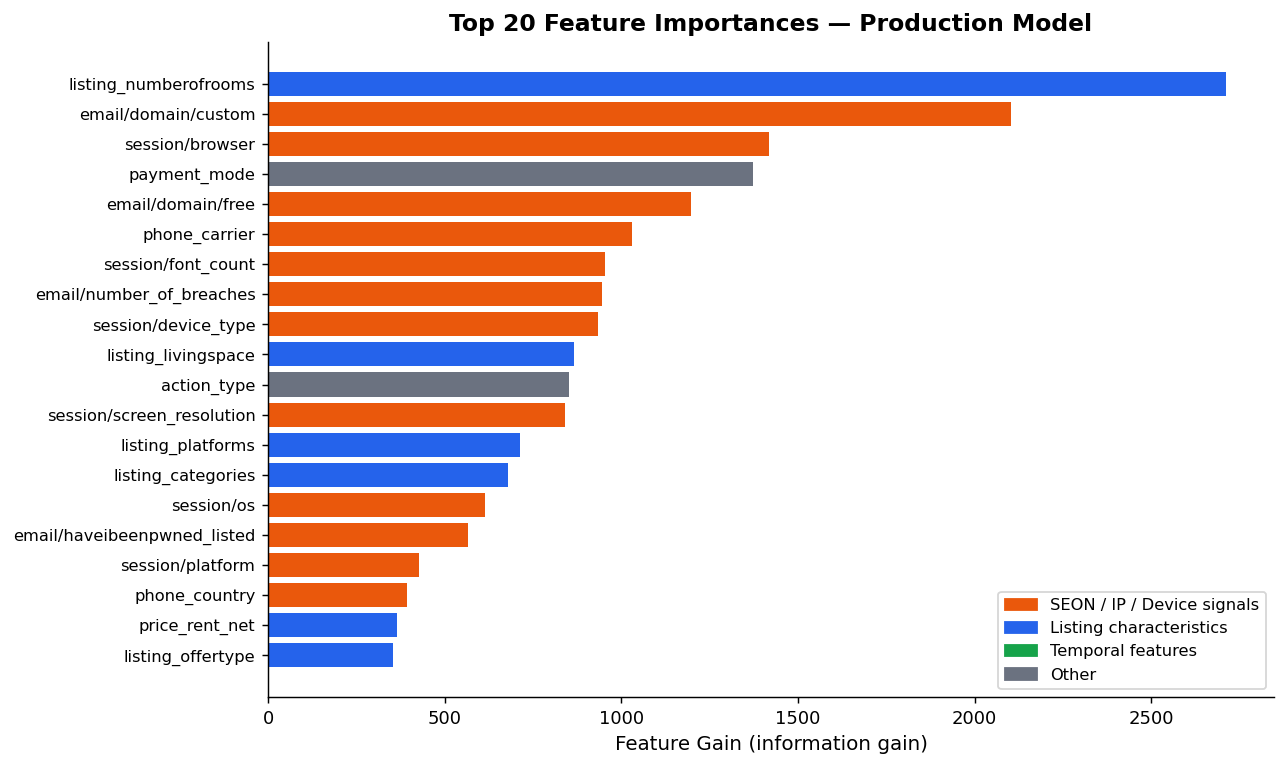

In [6]:
import mlflow
import xgboost as xgb

mlflow.set_tracking_uri('sqlite:///../ppa-fraud-detection-mlflow.db')
model = mlflow.xgboost.load_model('models:/fraud-detection@production')

importances = model.get_booster().get_score(importance_type='gain')
imp_df = pd.DataFrame(list(importances.items()), columns=['feature', 'gain'])
imp_df = imp_df.sort_values('gain', ascending=False).head(20)

# Clean up feature names for display
def clean_name(f):
    replacements = {
        'email/': 'email/', 'session/': 'session/',
        'LISTING_PRICES_': 'price_',
        'LISTING_CHARACTERISTICS_': 'listing_',
        'LISTING_': 'listing_',
    }
    for k, v in replacements.items():
        f = f.replace(k, v)
    return f.lower()

imp_df['clean'] = imp_df['feature'].apply(clean_name)

# Colour by category
def cat_color(f):
    if 'seon' in f or 'email/' in f or 'phone' in f or 'ip_' in f or 'proxy' in f or 'vpn' in f or 'tor' in f or 'session/' in f:
        return C_ORANGE
    if 'price' in f or 'listing' in f or 'rooms' in f or 'space' in f:
        return C_BLUE
    if 'event_' in f or 'hour' in f or 'weekday' in f:
        return C_GREEN
    return C_GREY

bar_colors = [cat_color(f) for f in imp_df['clean']]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(range(len(imp_df)), imp_df['gain'], color=bar_colors)
ax.set_yticks(range(len(imp_df)))
ax.set_yticklabels(imp_df['clean'], fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('Feature Gain (information gain)')
ax.set_title('Top 20 Feature Importances — Production Model', fontweight='bold')

legend_patches = [
    mpatches.Patch(color=C_ORANGE, label='SEON / IP / Device signals'),
    mpatches.Patch(color=C_BLUE,   label='Listing characteristics'),
    mpatches.Patch(color=C_GREEN,  label='Temporal features'),
    mpatches.Patch(color=C_GREY,   label='Other'),
]
ax.legend(handles=legend_patches, loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig('../artifacts/plots/feature_importance.png', bbox_inches='tight')
plt.show()

## 6  Summary Scorecard

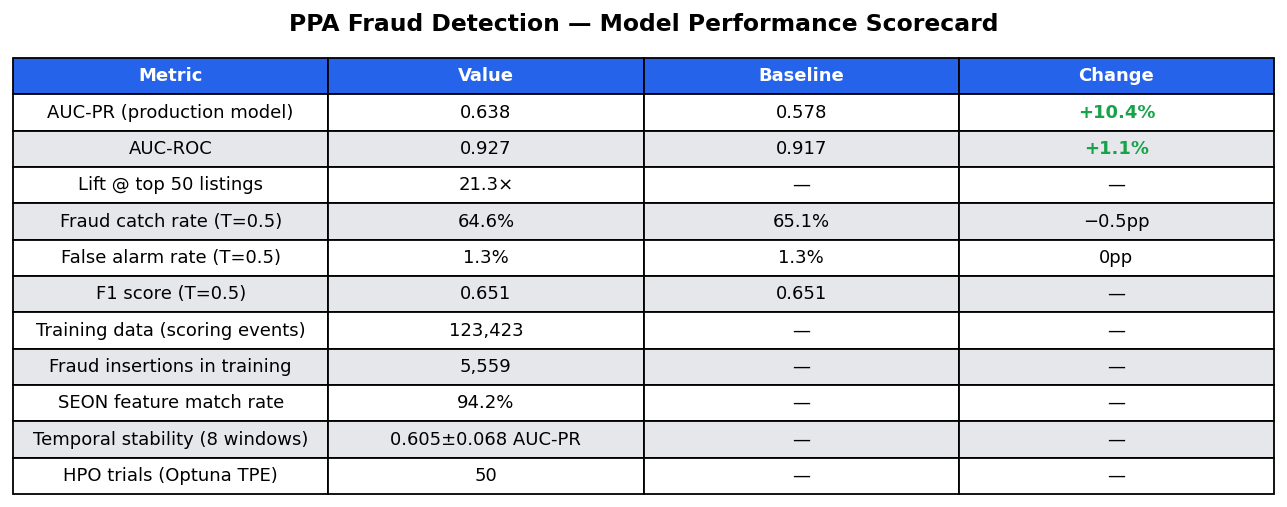

In [7]:
scorecard = pd.DataFrame([
    {'Metric': 'AUC-PR (production model)',       'Value': '0.638',    'Baseline': '0.578', 'Change': '+10.4%'},
    {'Metric': 'AUC-ROC',                         'Value': '0.927',    'Baseline': '0.917', 'Change': '+1.1%'},
    {'Metric': 'Lift @ top 50 listings',          'Value': '21.3×',    'Baseline': '—',     'Change': '—'},
    {'Metric': 'Fraud catch rate (T=0.5)',         'Value': '64.6%',    'Baseline': '65.1%', 'Change': '−0.5pp'},
    {'Metric': 'False alarm rate (T=0.5)',         'Value': '1.3%',     'Baseline': '1.3%',  'Change': '0pp'},
    {'Metric': 'F1 score (T=0.5)',                 'Value': '0.651',    'Baseline': '0.651', 'Change': '—'},
    {'Metric': 'Training data (scoring events)',   'Value': '123,423',  'Baseline': '—',     'Change': '—'},
    {'Metric': 'Fraud insertions in training',     'Value': '5,559',    'Baseline': '—',     'Change': '—'},
    {'Metric': 'SEON feature match rate',          'Value': '94.2%',    'Baseline': '—',     'Change': '—'},
    {'Metric': 'Temporal stability (8 windows)',   'Value': '0.605±0.068 AUC-PR', 'Baseline': '—', 'Change': '—'},
    {'Metric': 'HPO trials (Optuna TPE)',          'Value': '50',       'Baseline': '—',     'Change': '—'},
])

fig, ax = plt.subplots(figsize=(10, 4))
ax.axis('off')
table = ax.table(
    cellText=scorecard.values,
    colLabels=scorecard.columns,
    cellLoc='center',
    loc='center',
    bbox=[0, 0, 1, 1],
)
table.auto_set_font_size(False)
table.set_fontsize(10)

# Header styling
for j in range(len(scorecard.columns)):
    table[0, j].set_facecolor(C_BLUE)
    table[0, j].set_text_props(color='white', fontweight='bold')

# Alternating rows
for i in range(1, len(scorecard) + 1):
    bg = C_LIGHT if i % 2 == 0 else 'white'
    for j in range(len(scorecard.columns)):
        table[i, j].set_facecolor(bg)

# Highlight improvements
for i, row in enumerate(scorecard.itertuples(), 1):
    if '+' in str(row.Change):
        table[i, 3].set_text_props(color=C_GREEN, fontweight='bold')

plt.title('PPA Fraud Detection — Model Performance Scorecard', fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('../artifacts/plots/scorecard.png', bbox_inches='tight', dpi=150)
plt.show()

---
## Export all plots

In [8]:
import os
os.makedirs('../artifacts/plots', exist_ok=True)
print('All plots saved to artifacts/plots/')
for f in sorted(os.listdir('../artifacts/plots')):
    print(' ', f)

All plots saved to artifacts/plots/
  expanding_window.png
  feature_importance.png
  hpo_trials.png
  scorecard.png
  temporal_stability.png
  threshold_tradeoff.png
